# Generalizability

By the end of [chapter 5](../5_hyperparameter_optimization/index.md) we had an honest recipe: put
everything in a pipeline, tune by inner cross-validation, estimate performance by an outer one,
compare against a baseline. Follow it and the number you report is not inflated by overfitting or
by leakage.

It is still not the number you actually care about.

Cross-validation estimates how well your model predicts **new participants drawn like yours** —
same scanner, same recruitment, same preprocessing, same decade. The question a clinician asks is
how well it predicts *their* patients, in *their* hospital, next year. That is a different
question, and the gap between the two is the subject of this chapter.

## Internal and external validation

The vocabulary is worth fixing.

- **Internal validation** re-uses one dataset: train-test splits, cross-validation, the bootstrap.
  It answers: *given data from this distribution, does my procedure produce a model that works on
  more data from this distribution?*
- **External validation** applies the frozen model to data collected separately — another site,
  another cohort, another time — and answers: *does it work over there?*

Internal validation is cheap and answers a narrow question. External validation is expensive and
answers the question you actually asked. They are not interchangeable, and — this is the part that
surprises people — a perfectly executed internal validation does not put an upper bound on how
badly external validation can go.

## A worked example: how large is the gap?

It is rare for a single paper to report both numbers honestly, which is what makes
{cite:p}`kincses2024rcpl` such a useful teaching case. The study asks whether resting-state
functional connectivity — a five-minute scan in which the participant does nothing — can predict
how strongly that person learns from pain.

The methodology is close to the recipe of this book, and in one respect goes beyond it:

- feature selection and hyperparameter tuning inside a **nested** leave-one-participant-out
  cross-validation, so no leakage through the tuning;
- the final model — ten connections, a fixed regularization strength, and every preprocessing
  parameter — **frozen and publicly pre-registered** before the validation data were analyzed;
- **two independent validation cohorts**, one of which used a different paradigm, different
  personnel and a different pain modality (visceral rather than heat).

The results:

| | correlation between predicted and observed | variance explained |
|---|---|---|
| discovery sample (n = 25), nested cross-validation | **r = 0.72** | ~52% |
| external validation (n = 49, two cohorts) | **r = 0.34** | **8–12%** |

Same model. Same lab. Same scanner. Cross-validated exactly as this book recommends. And roughly
**five-sixths of the explained variance evaporated** on contact with new data.

```{margin} Which number is in the abstract?
The external one. The paper leads with 8–12% variance explained rather than with r = 0.72, and
calls the discrepancy "remarkable" in the discussion. That is the behaviour to imitate: if you
have both numbers, the honest headline is the one from the data that did not shape the model.
```

The authors' own explanation has two parts, and neither is misconduct. First, cross-validation in
a small sample is *unbiased but highly variable*: the estimate is right on average over many
hypothetical studies, and any one study can land far above the truth by luck — with n = 25, far
above. Second, even a pre-registered pipeline leaves some analytic flexibility during the
discovery phase, and flexibility inflates whatever is measured on the data it was exercised on.

## Why generalization fails: a taxonomy

It helps to be specific about *what* differs between your data and the new data. Write the joint
distribution as $P(X, y)$, and there are three canonical ways for it to move.

**Covariate shift**: $P(X)$ changes, $P(y \mid X)$ stays. Your new site scans older participants,
or uses a different sequence that changes the intensity distribution, but the relationship between
brain structure and age is the same. This is the mildest case and sometimes correctable.

**Label shift**: $P(y)$ changes. Your model was developed in a cohort where 50% of participants
had the disorder, and is deployed where 2% do. Nothing about the biology changed, but every
probability the model outputs is now miscalibrated, and the positive predictive value collapses.

**Concept drift**: $P(y \mid X)$ itself changes. Diagnostic criteria are revised; treatment
practice changes what the measurement means; a proxy that used to track the target stops tracking
it. This is the one that no amount of reweighting can fix.

To these, biomedical data adds a fourth that cuts across all three: **site and scanner effects**.
Different hardware, sequences and preprocessing produce systematic differences in the features
themselves, large enough that a model can learn to identify the *site* and ride that signal — which
works beautifully until it meets a site it has never seen.

## Seeing it happen

We can produce a distribution shift on the IXI data without simulating anything, because the file
comes with one built in. As we saw in [chapter 1](../1_python_basics/data_frames.ipynb), the rows
are ordered such that mean age drifts substantially across the file. Splitting by position rather
than at random therefore gives us two genuinely different populations — which is exactly what we
have been carefully avoiding all book, and exactly what we now want.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, KFold, learning_curve
from sklearn.metrics import mean_absolute_error

DATA_URL = "https://raw.githubusercontent.com/pni-lab/predmod_lecture/master/ex_data/IXI/ixi.csv"

ixi_ordered = pd.read_csv(DATA_URL)                      # deliberately NOT shuffled here
TARGET = 'Age'
FEATURES = [c for c in ixi_ordered.columns if c.endswith('_volume')]

# two "sites": the first and the last third of the file
site_a = ixi_ordered.iloc[:210].reset_index(drop=True)
site_b = ixi_ordered.iloc[-210:].reset_index(drop=True)

print(f'site A: n={len(site_a)}, mean age {site_a[TARGET].mean():.1f} '
      f'(range {site_a[TARGET].min():.0f}-{site_a[TARGET].max():.0f})')
print(f'site B: n={len(site_b)}, mean age {site_b[TARGET].mean():.1f} '
      f'(range {site_b[TARGET].min():.0f}-{site_b[TARGET].max():.0f})')

site A: n=210, mean age 40.8 (range 20-83)
site B: n=210, mean age 57.6 (range 25-86)


In [2]:
model = Pipeline([('standardize', StandardScaler()), ('regression', Ridge(alpha=100))])

# internal validation on site A
internal = cross_val_predict(model, X=site_a[FEATURES], y=site_a[TARGET], cv=KFold(5))
internal_mae = mean_absolute_error(site_a[TARGET], internal)

# external validation: freeze the model trained on site A, apply it to site B
model.fit(X=site_a[FEATURES], y=site_a[TARGET])
external = model.predict(site_b[FEATURES])
external_mae = mean_absolute_error(site_b[TARGET], external)

baseline_a = mean_absolute_error(site_a[TARGET], np.full(len(site_a), site_a[TARGET].mean()))
baseline_b = mean_absolute_error(site_b[TARGET], np.full(len(site_b), site_a[TARGET].mean()))


def report(true, predicted, label, baseline):
    true, predicted = np.asarray(true), np.asarray(predicted)
    return {'validation': label,
            'MAE (years)': mean_absolute_error(true, predicted),
            'baseline MAE': baseline,
            'correlation r': np.corrcoef(true, predicted)[0, 1],
            'mean signed error': np.mean(predicted - true)}


pd.DataFrame([report(site_a[TARGET], internal, 'internal (within site A)', baseline_a),
              report(site_b[TARGET], external, 'external (site A -> site B)', baseline_b)]).round(2)

,validation,MAE (years),baseline MAE,correlation r,mean signed error
0,internal (within site A),9.53,12.44,0.61,-0.09
1,external (site A -> site B),13.64,20.30,0.67,-10.56


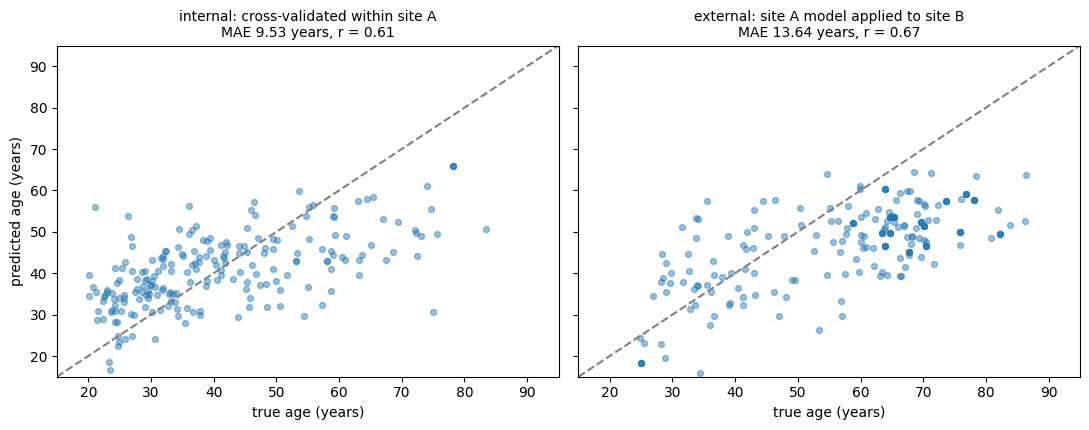

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
for ax, (true, pred, name) in zip(
        axes,
        [(site_a[TARGET], internal, 'internal: cross-validated within site A'),
         (site_b[TARGET], external, 'external: site A model applied to site B')]):
    ax.scatter(true, pred, alpha=0.45, s=18)
    limits = [15, 95]
    ax.plot(limits, limits, ls='--', color='0.5')
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_xlabel('true age (years)')
    ax.set_title(f'{name}\nMAE {mean_absolute_error(true, pred):.2f} years, '
                 f'r = {np.corrcoef(true, pred)[0, 1]:.2f}', fontsize=10)
axes[0].set_ylabel('predicted age (years)')
plt.tight_layout()
plt.show()

Look carefully, because this is not the failure you were expecting.

The **correlation went up**, from 0.61 to 0.67. By that measure the model generalized *better* to
the new site than it did to held-out data from its own. And yet the mean absolute error rose by
more than four years.

The mean signed error says what happened: in site A the model is unbiased (−0.09 years), and in
site B it is **10.6 years too low, on average**. It was fitted in a population with a mean age of
41 and applied to one with a mean age of 58, and it brought its training population's centre of
gravity with it. The ordering of participants is preserved — hence the correlation — while every
individual prediction is wrong in the same direction.

This is **label shift** in its purest form: $P(y)$ moved, the age–brain relationship did not. And
it makes concrete the warning from [chapter 2](../2_linear_models/theory_linear_models.md): a
model that is systematically ten years off can still correlate beautifully with the truth. A paper
reporting only $r$ would present this as a successful external validation.

```{margin} Report both, always
Correlation measures whether you ranked people correctly; error measures whether you got their
values right. Shifts of this kind destroy the second while leaving the first intact. This is also
why the two baselines differ so much (12.4 versus 20.3 years): site B simply spans a wider spread
of ages around site A's mean, so the trivial predictor is worse there too.
```

The good news about label shift is that it is the most tractable of the three. Because the *shape*
of the relationship survived, a **recalibration** — re-estimating an intercept, or an intercept and
slope, on a modest number of participants from the new site — recovers most of the loss. The catch
is that recalibration needs *labelled* data from the new site, which is precisely what you often do
not have. And recalibration cannot rescue you from concept drift, where the relationship itself
has changed.

:::{admonition} Exercise 6.1
:class: tip, dropdown
Reverse the experiment: train on site B and validate on site A. Is the degradation symmetric?

:::{admonition} Solution
:class: note, dropdown
It is not. Extrapolation is not symmetric in general: a model trained on a wide age range and
applied to a narrow one behaves quite differently from the reverse, and which direction hurts more
depends on where the relationship is steep and how much data supports each region. The practical
lesson is that "we validated across sites" is not a single property — it matters *which* site was
the training one.
:::
:::

## How much data is enough?

One recurring reason models fail to generalize is simply that they were developed on too few
participants — the RCPL discovery sample was 25. The tool for thinking about this is the
**learning curve**: performance as a function of training set size.

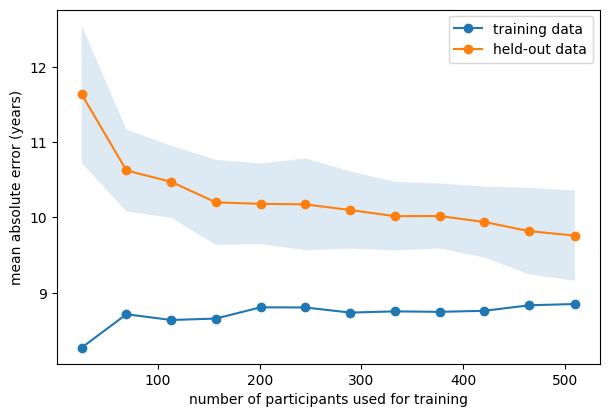

held-out MAE at n=25: 11.63 years
held-out MAE at n=510: 9.76 years


In [4]:
ixi = ixi_ordered.sample(frac=1, random_state=42).reset_index(drop=True)   # back to honest splits

sizes, train_scores, test_scores = learning_curve(
    model, X=ixi[FEATURES], y=ixi[TARGET],
    train_sizes=np.linspace(0.05, 1.0, 12), cv=KFold(5),
    scoring='neg_mean_absolute_error', shuffle=True, random_state=42)

train_mae = -train_scores.mean(axis=1)
test_mae = -test_scores.mean(axis=1)
test_sd = test_scores.std(axis=1)

plt.figure(figsize=(7, 4.6))
plt.plot(sizes, train_mae, marker='o', label='training data')
plt.plot(sizes, test_mae, marker='o', label='held-out data')
plt.fill_between(sizes, test_mae - test_sd, test_mae + test_sd, alpha=0.15)
plt.xlabel('number of participants used for training')
plt.ylabel('mean absolute error (years)')
plt.legend()
plt.show()

print(f'held-out MAE at n={sizes[0]:.0f}: {test_mae[0]:.2f} years')
print(f'held-out MAE at n={sizes[-1]:.0f}: {test_mae[-1]:.2f} years')

Two things to read off a learning curve.

**Is it still falling?** If the held-out curve has not flattened, more participants would buy more
accuracy, and your model is data-limited rather than method-limited. Trying a fancier algorithm is
then usually a worse investment than collecting more data.

**How wide is the band?** The shaded region is the spread across folds. At small training sizes it
is enormous — which is the RCPL lesson in picture form. A cross-validated estimate from a small
sample is a draw from a wide distribution, and papers are preferentially written about the lucky
draws.

```{note}
This is the reason behind the sample-size debate in brain-wide association studies. Reported
brain-behaviour effects were shown to be substantially inflated at the sample sizes typical of the
field, with replicable effects requiring far larger samples than were customary
{cite:p}`spisak2023multivariate`. The argument is not that small studies are dishonest; it is that
small-sample estimates are *variable*, and publication selects from the top of a variable
distribution.
```

## What to do about it

**Validate externally, and say so plainly.** If you have only internal validation, report it as
internal validation. A model that has never met independent data is a hypothesis.

**Freeze and pre-register the model.** The RCPL "registered model" design — fix every parameter,
publish it, *then* collect or unlock the validation data — makes leakage and flexible analysis
arithmetically impossible rather than merely unlikely.

**Design the splits to match the deployment question.** If your model will be used at a new
hospital, leave-one-*site*-out cross-validation estimates the thing you care about, and a random
split does not. Scikit-learn's `GroupKFold` and `LeaveOneGroupOut` exist for this.

**Harmonize, then check.** Methods such as ComBat can reduce site effects in the features. They do
not reliably remove them, and you must verify rather than assume — which is the subject of
[the next page](validity.ipynb).

**Report the population, not just the performance.** Age range, sex distribution, scanner,
sequence, recruitment, inclusion criteria. An MAE without a described population is not
interpretable, because someone else's MAE on a narrower cohort will look better for no good
reason.

:::{admonition} Exercise 6.2
:class: tip, dropdown
Our site A/site B split confounds two things: the age distribution differs, *and* the
participants may have been scanned differently. With the data at hand, can you tell these apart?
What would you need in order to?

:::{admonition} Solution
:class: note, dropdown
You cannot, and that is the point. The CSV has no site variable, so scanner differences and age
differences are perfectly entangled in this split. To separate them you would need the site labels,
and then either a site-stratified split (equal age distributions across sites) or the conditional
tests of [the next page](validity.ipynb). The general lesson: when two explanations for a
performance drop are confounded by design, no analysis of that dataset can adjudicate between them
— you need the metadata, and you need it recorded before the fact.
:::
:::

:::{admonition} Exercise 6.3
:class: tip, dropdown
Plot the learning curve for the unregularized `LinearRegression` instead of `Ridge(alpha=100)`.
At which sample size does the difference between them stop mattering?
:::

Generalization asks whether the model still works elsewhere. [The next page](validity.ipynb) asks
a harder question: whether what it learned was ever the thing you thought it was.